In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')
import matplotlib.pyplot as plt

In [10]:
from impact.fieldmaps import process_fieldmap_solrf, fieldmap_reconsruction

# new parser

In [11]:


from impact.tools import safe_loadtxt

def process_fieldmap_newsolrf(data):
    """
    Processes new-style rfdata (table with 4 columns)
    The format is:
    ne, zmin, zmax, L 
    Ez, Ez', Ez'', Ez'''
    ... ne times
    nb, zmin, zmax, L 
    Bz, Bz', Bz'', Bz'''
    
    """
    
    d = {}
    d['Ez'] = {}
    d['Bz'] = {}
    
    # Ez
    header = data[0]
    n = int(header[0])
    d['Ez']['z0'] = header[1] # distance before the zedge.
    d['Ez']['z1'] = header[2] # distance after the zedge.
    d['Ez']['L']  = header[3] # length 
    i1 = 1
    i2 = 1+n
    d['Ez']['field'] = data[i1:i2] 
    
    # Bz
    data2 = data[i2:]
    header2 = data2[0]
    n = int(header2[0])
    d['Bz']['z0'] = header2[1] # distance before the zedge.
    d['Bz']['z1'] = header2[2] # distance after the zedge.
    d['Bz']['L']  = header2[3] # length
    i1 = 1
    i2 = 1+n
    d['Bz']['field'] = data2[i1:i2] 
    
    return d



In [12]:
fmap2 = process_fieldmap_newsolrf(safe_loadtxt('rfdata2'))
fmap3 = process_fieldmap_newsolrf(safe_loadtxt('rfdata3'))
fmap5 = process_fieldmap_newsolrf(safe_loadtxt('rfdata5'))
fmap30 = process_fieldmap_newsolrf(safe_loadtxt('rfdata30'))

In [13]:
ofmap1 = process_fieldmap_solrf(safe_loadtxt('../v1/rfdata1'))
ofmap2 = process_fieldmap_solrf(safe_loadtxt('../v1/rfdata2'))
ofmap3 = process_fieldmap_solrf(safe_loadtxt('../v1/rfdata3'))
ofmap9 = process_fieldmap_solrf(safe_loadtxt('../v1/rfdata9'))

# Gun

In [14]:
fmap30

{'Ez': {'z0': -0.199,
  'z1': 0.199,
  'L': 0.398,
  'field': array([[ 2.44946423e-05, -6.87614011e-06,  2.56370711e+00,
           1.96007049e+00],
         [ 2.46883556e-05,  1.00142346e-03,  2.48585486e+00,
          -3.90672668e+02],
         [ 2.52752779e-05,  1.95582071e-03,  2.25571775e+00,
          -7.59051208e+02],
         ...,
         [ 2.52891878e-05, -1.97257660e-03,  2.25265527e+00,
           7.62686584e+02],
         [ 2.46967320e-05, -1.01907656e-03,  2.48428512e+00,
           3.94532043e+02],
         [ 2.44946441e-05, -1.10986166e-05,  2.56370664e+00,
           1.97540653e+00]])},
 'Bz': {'z0': 0.0, 'z1': 0.0, 'L': 0.0, 'field': array([[0., 0., 0., 0.]])}}

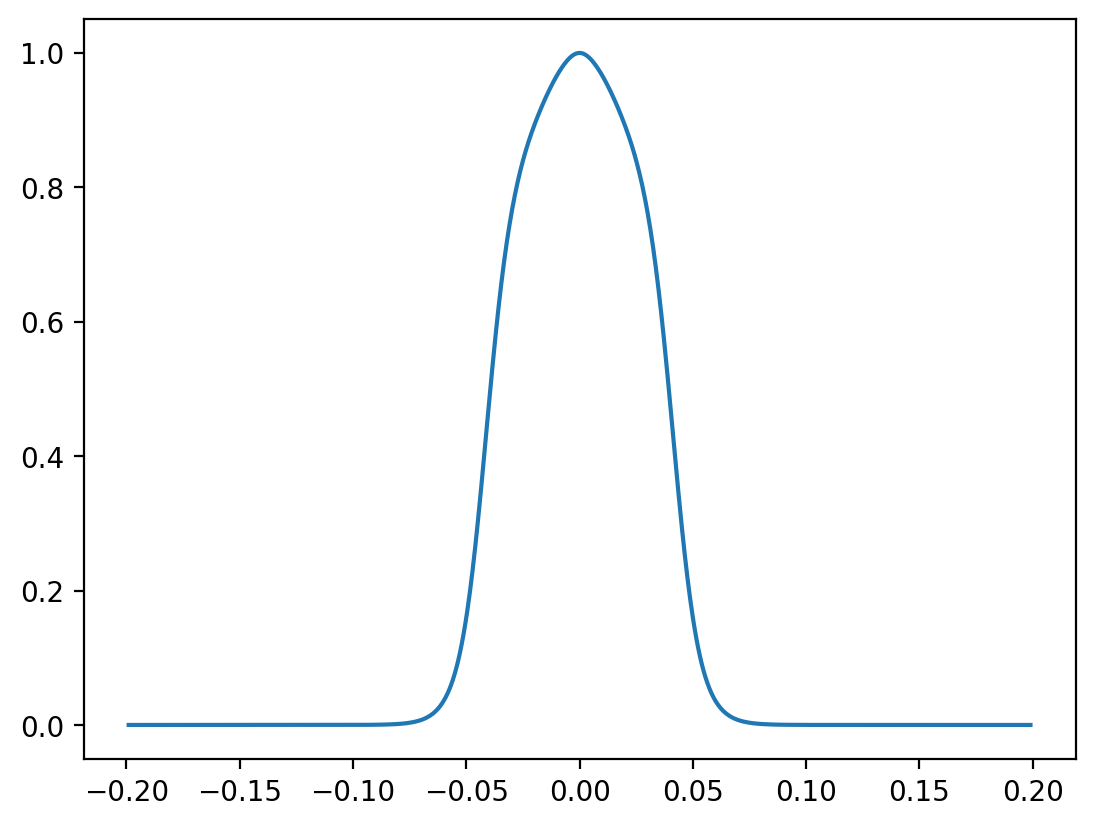

In [15]:
fmap = fmap30

Ez0 = fmap['Ez']['field'][:,0]
z0 = np.linspace(fmap['Ez']['z0'], fmap['Ez']['z1'], len(Ez0))


plt.plot(z0, Ez0)

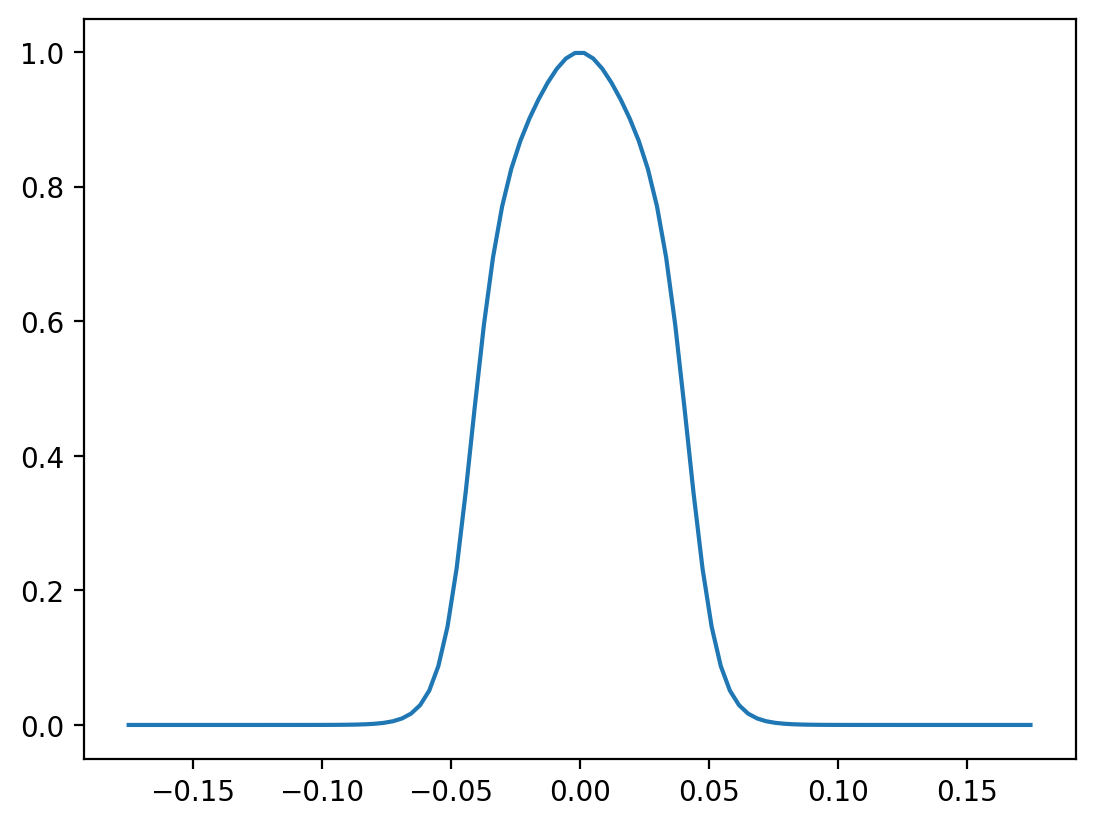

In [16]:
# Old fieldmap
oEz = ofmap1['Ez']
z1 = np.linspace(oEz['z0'], oEz['z1'], 100)
Ez1 = np.array([fieldmap_reconsruction(oEz, z) for z in z1])

plt.plot(z1, Ez1)

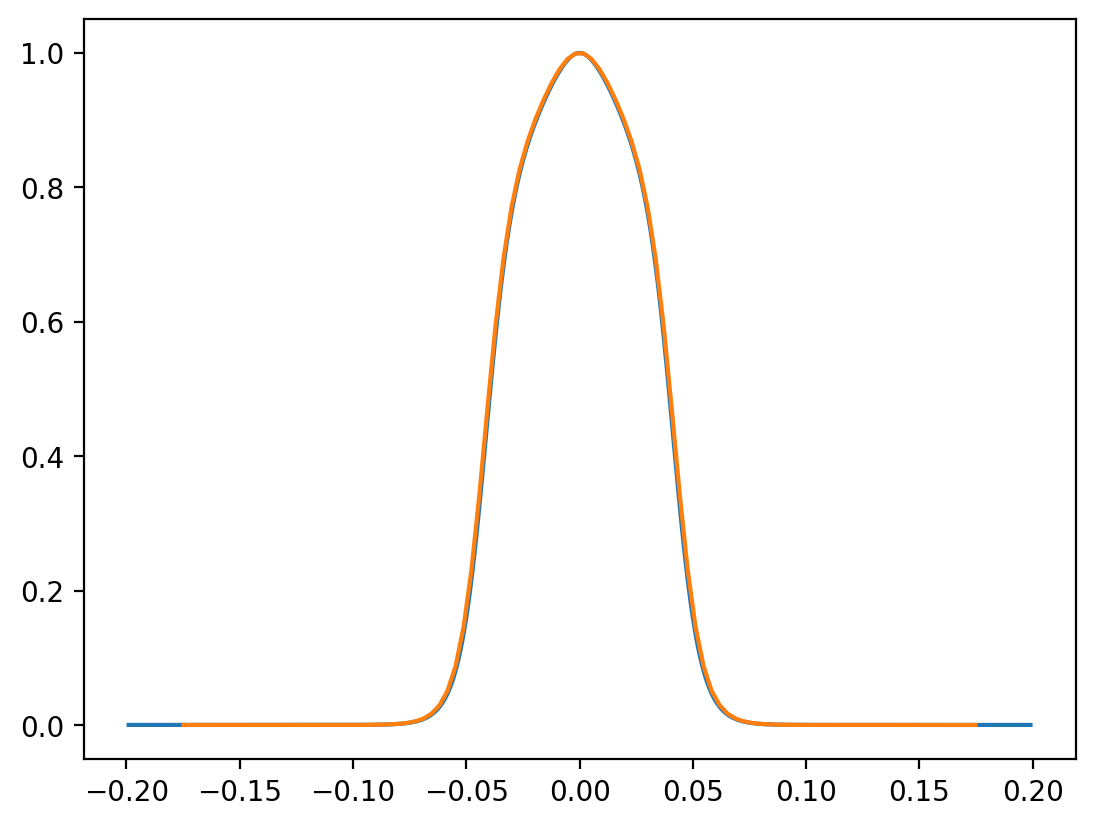

In [17]:
fig, ax = plt.subplots()
ax.plot(z0, Ez0, label='new')
ax.plot(z1, Ez1, label='old')

# Solenoids

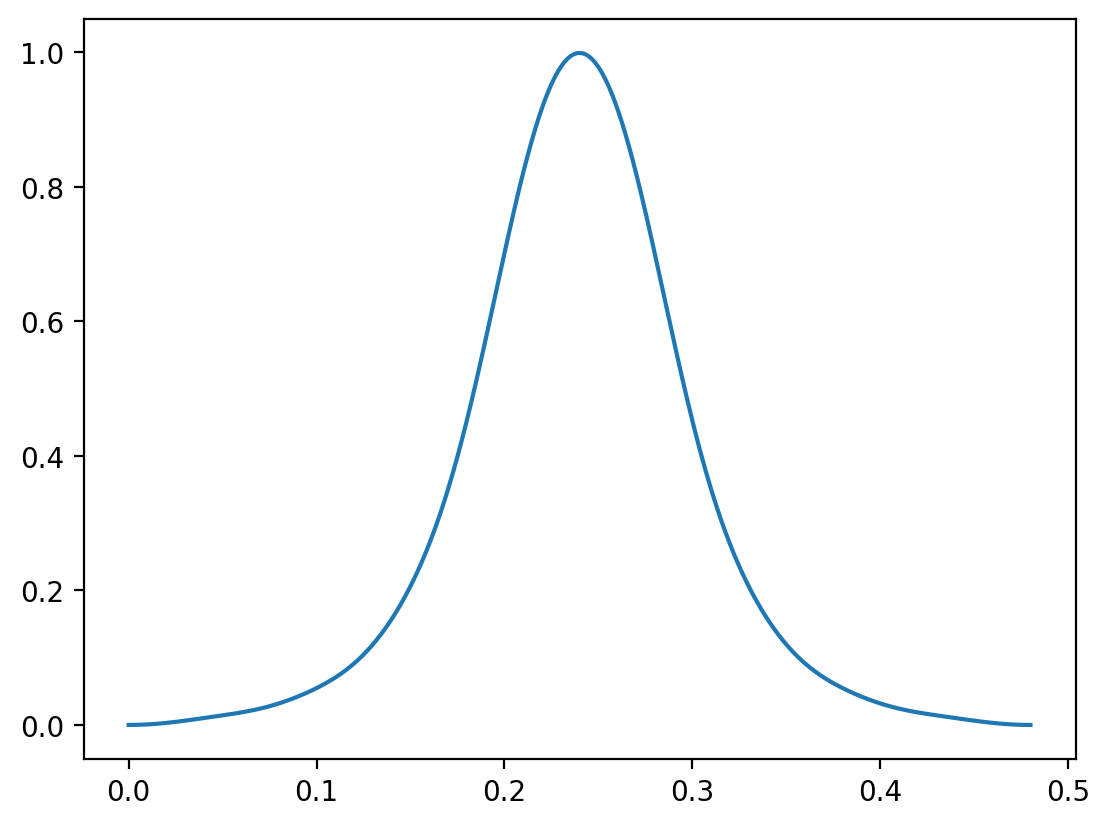

In [18]:
fmap = fmap5

# 0.48 105 20 105 0.00652999999999999d0 0.0 0.0 0.0 5.0 0.1 0.0 0.0 0.0 0.0 0.0 0.056 /
# 0.48 105 20 105 1.40581d0 0.0 0.0 0.0 5.0 0.1 0.0 0.0 0.0 0.0 0.0 0.03 /
# zedge0 = 0.00652999999999999
zedge0 = 1.40581

Bz0 = fmap['Bz']['field'][:,0]
z0 = np.linspace(fmap['Bz']['z0'], fmap['Bz']['z1'], len(Bz0))


plt.plot(z0, Bz0)

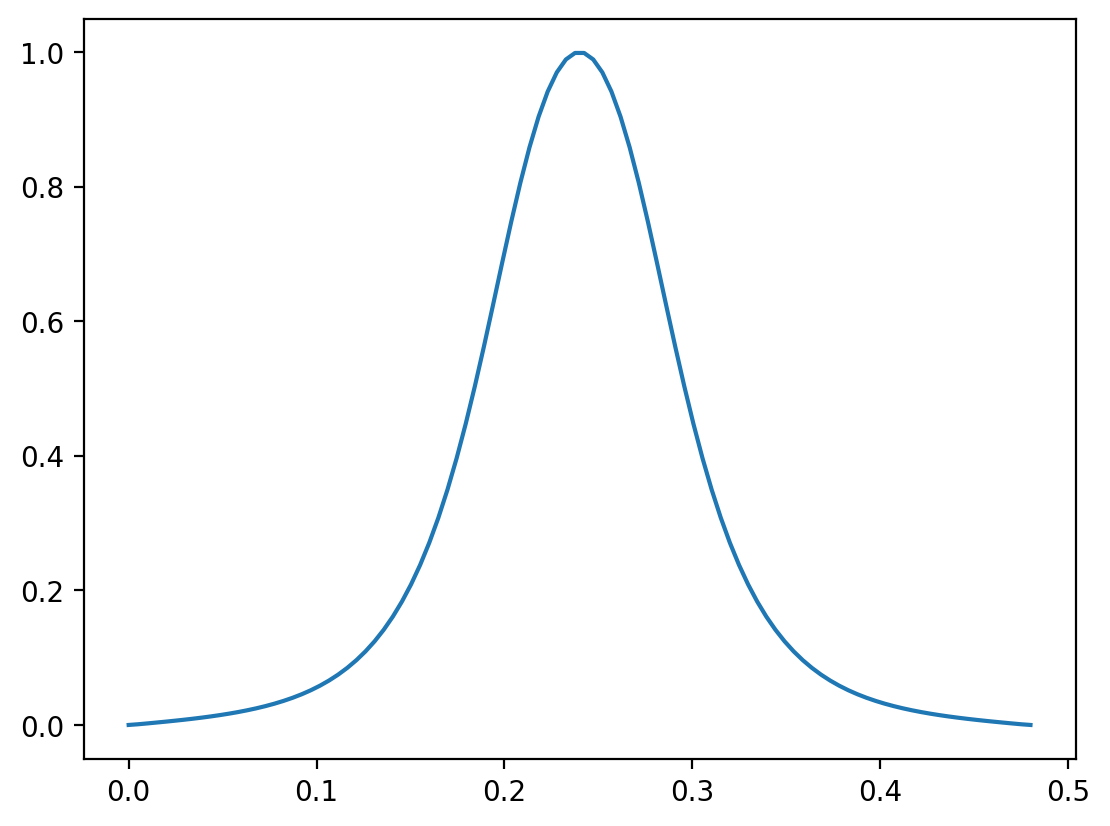

In [19]:
# Old fieldmap

# 0.48 0 0 105 0.006530000000000036 0 0 0 2 0.15 0.0 0.0 0.0 0.0 0.0 0.0559 /!name:SOL1B
# 0.48 0 0 105 1.40581 0 0 0 2 0.15 0.0 0.0 0.0 0.0 0.0 0.0299 /!name:SOL2B
#zedge1 = 0.006530000000000036
zedge1 = 1.40581

oBz = ofmap2['Bz']
z1 = np.linspace(oBz['z0'], oBz['z1'], 100)
Bz1 = np.array([fieldmap_reconsruction(oBz, z) for z in z1])

plt.plot(z1, Bz1)

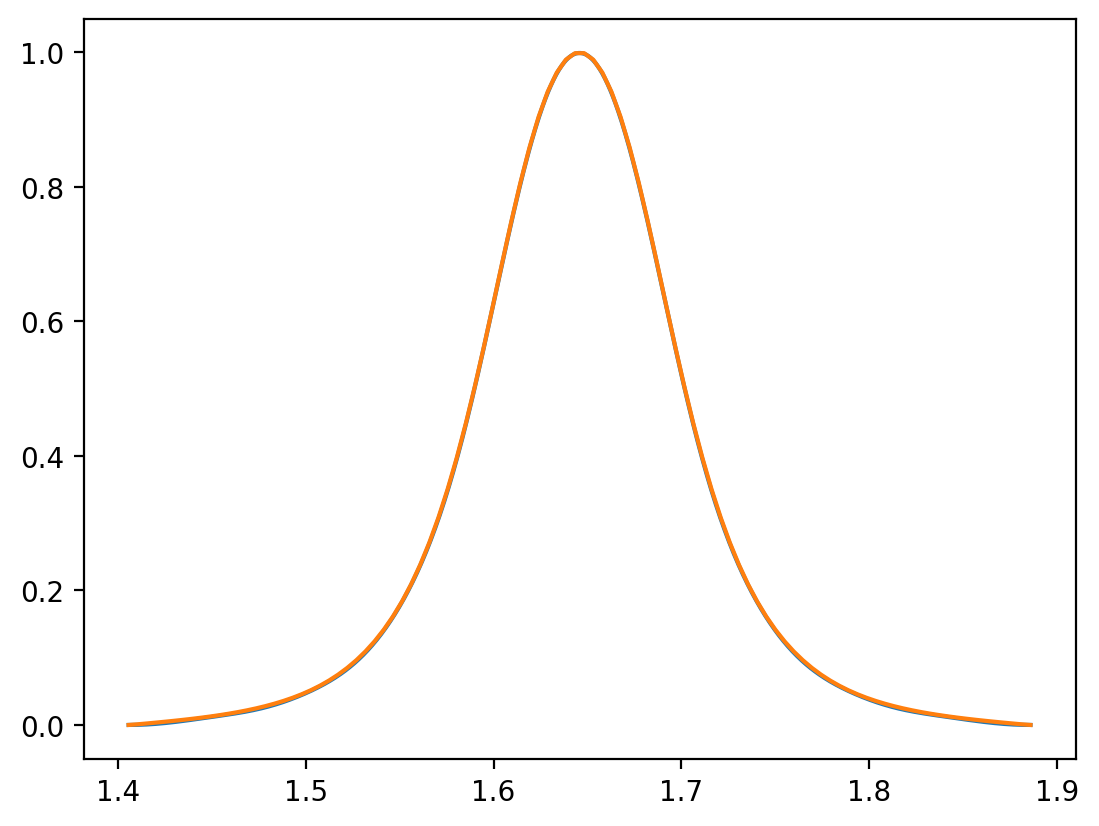

In [20]:
fig, ax = plt.subplots()
ax.plot(z0 + zedge0, Bz0, label='new')
ax.plot(z1 + zedge1, Bz1, label='old')

# Buncher

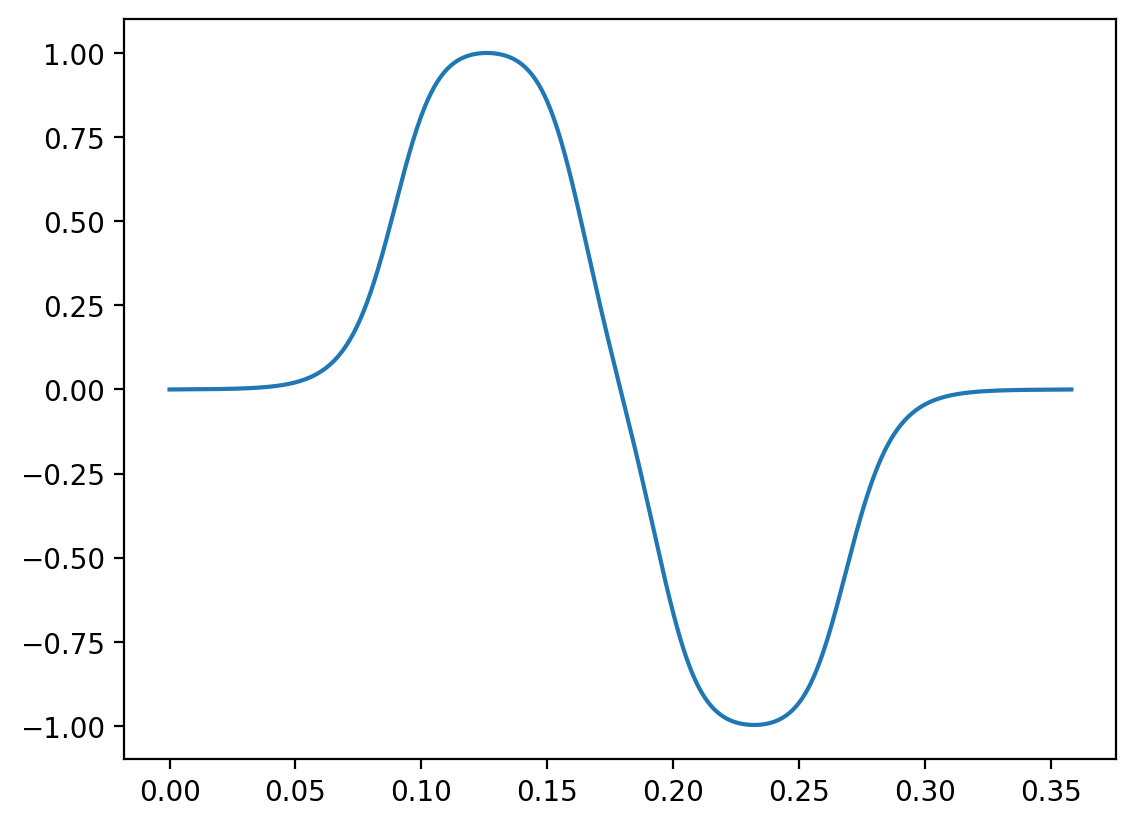

In [21]:
# !1.3GHz buncher, -88.5 degree w.r.p peak
#. 0.358133 105 20 105 0.6300495 -1.8d6 1.3d9 23.5633 2.0 0.1 0.0 0.0 0.0 0.0 0.0 0.0 /
zedge0 = 0.6300495

fmap = fmap2

Ez0 = fmap['Ez']['field'][:,0]
z0 = np.linspace(fmap['Ez']['z0'], fmap['Ez']['z1'], len(Ez0))

plt.plot(z0, Ez0)

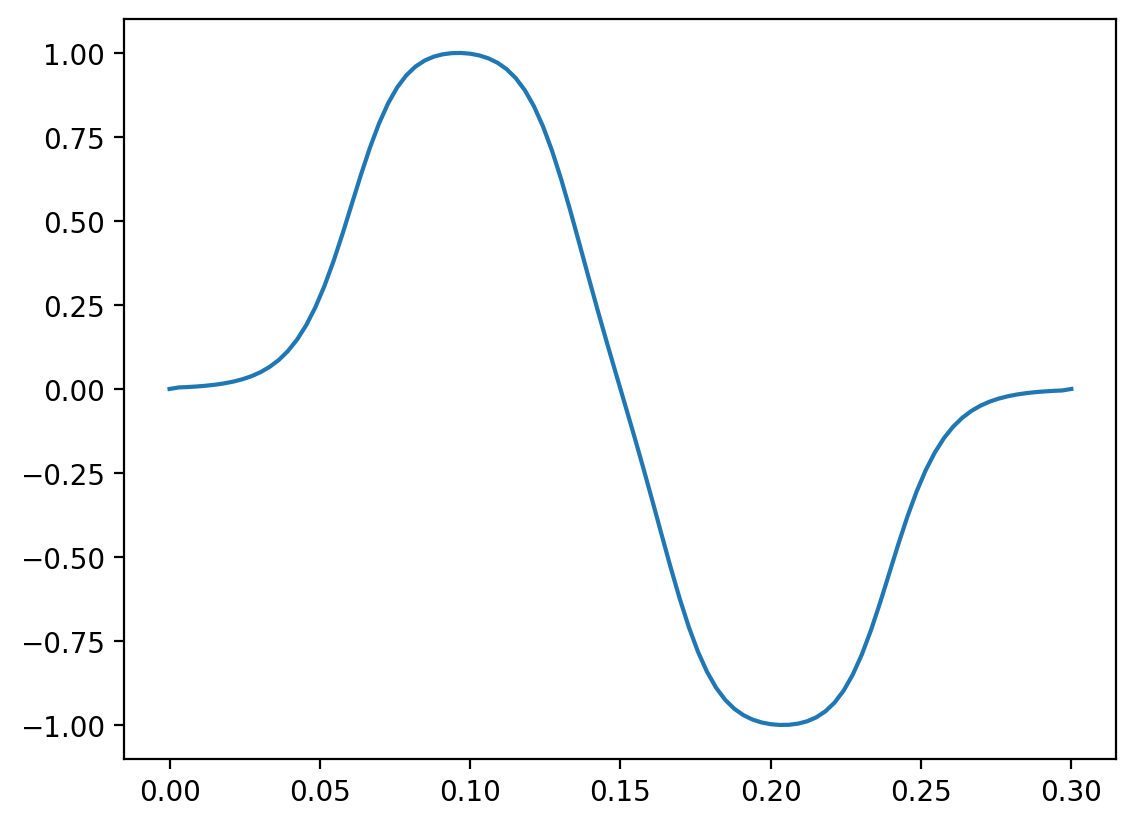

In [22]:
# Old fieldmap

#. 0.3 0 0 105 0.6591159999999999 1800000.0 1300000000.0 216.7685022621053 3 0.15 0.0 0.0 0.0 0.0 0.0 0 /!name:BUN1B
oEz = ofmap3['Ez']
zedge1 = 0.6591159999999999
z1 = np.linspace(oEz['z0'], oEz['z1'], 100)
Ez1 = np.array([fieldmap_reconsruction(oEz, z) for z in z1])

plt.plot(z1, Ez1)

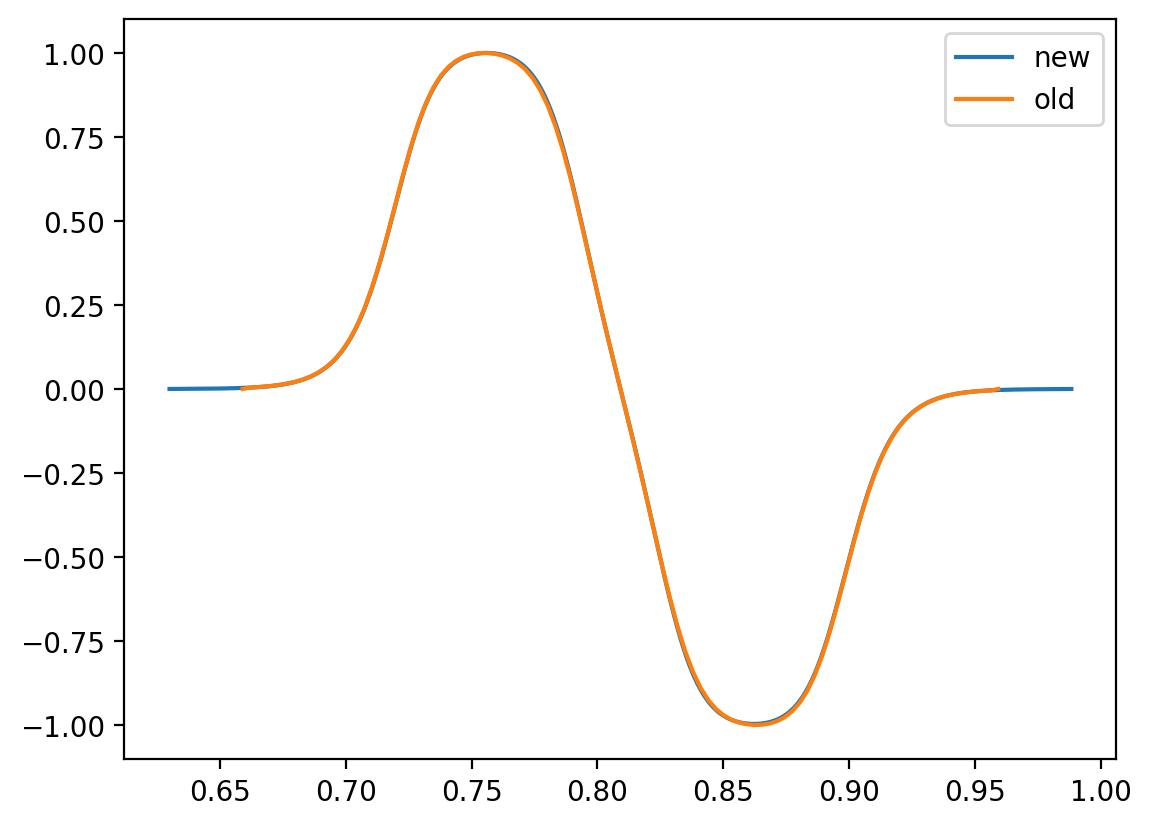

In [23]:
fig, ax = plt.subplots()
ax.plot(z0+zedge0, Ez0, label='new')
ax.plot(z1+zedge1, Ez1, label='old')
plt.legend()

# Cavities

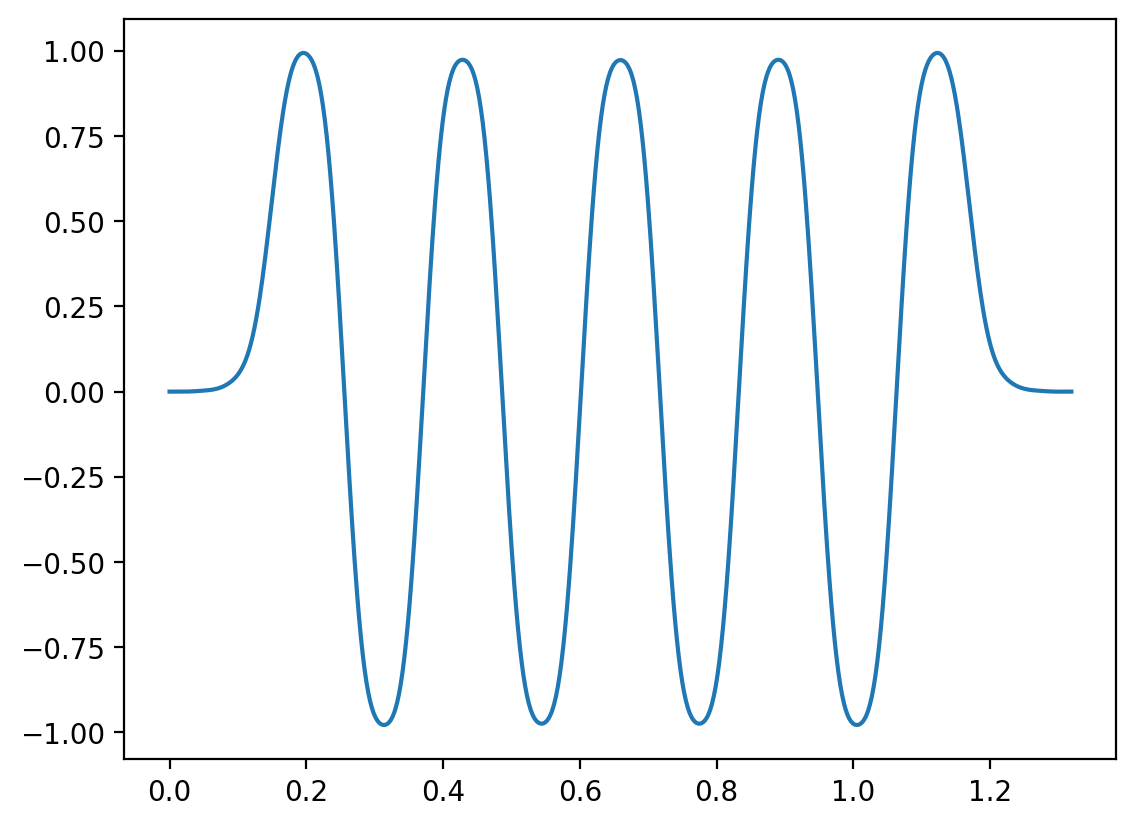

In [24]:
fmap = fmap3


# 1.318798d0 10 20 105 2.683401 -11d6 1.3d9 81.8476175814 3.0 0.1 0.0 0.0 0.0 0.0 0.0 0.0 /
zedge0 = 2.683401
Ez0 = fmap['Ez']['field'][:,0]
z0 = np.linspace(fmap['Ez']['z0'], fmap['Ez']['z1'], len(Ez0))


plt.plot(z0, Ez0)

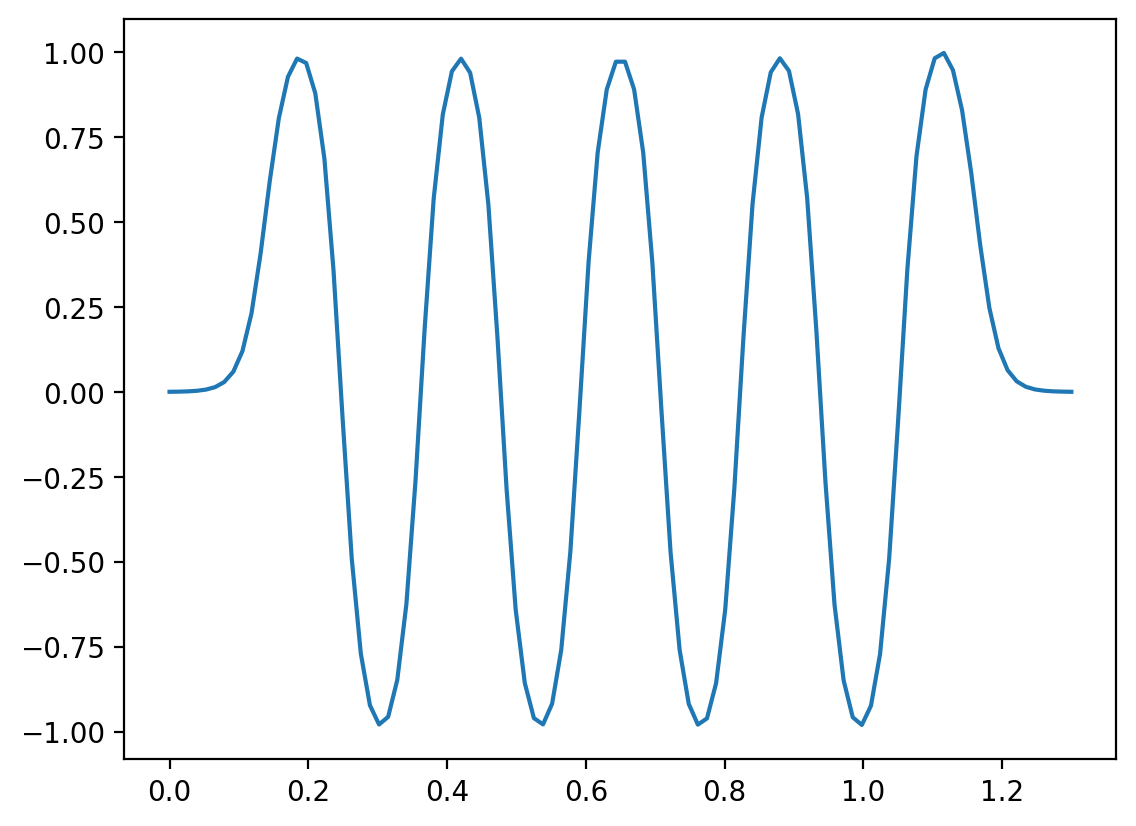

In [25]:
# Old fieldmap

# 1.3 0 0 105 2.6928270000000003 11000000.0 1300000000.0 279.7872241485336 9 0.15 0.0 0.0 0.0 0.0 0.0 0 /!name:CAVL011
zedge1 = 2.6928270000000003

oEz = ofmap9['Ez']
z1 = np.linspace(oEz['z0'], oEz['z1'], 100)
Ez1 = np.array([fieldmap_reconsruction(oEz, z) for z in z1])

plt.plot(z1, Ez1)

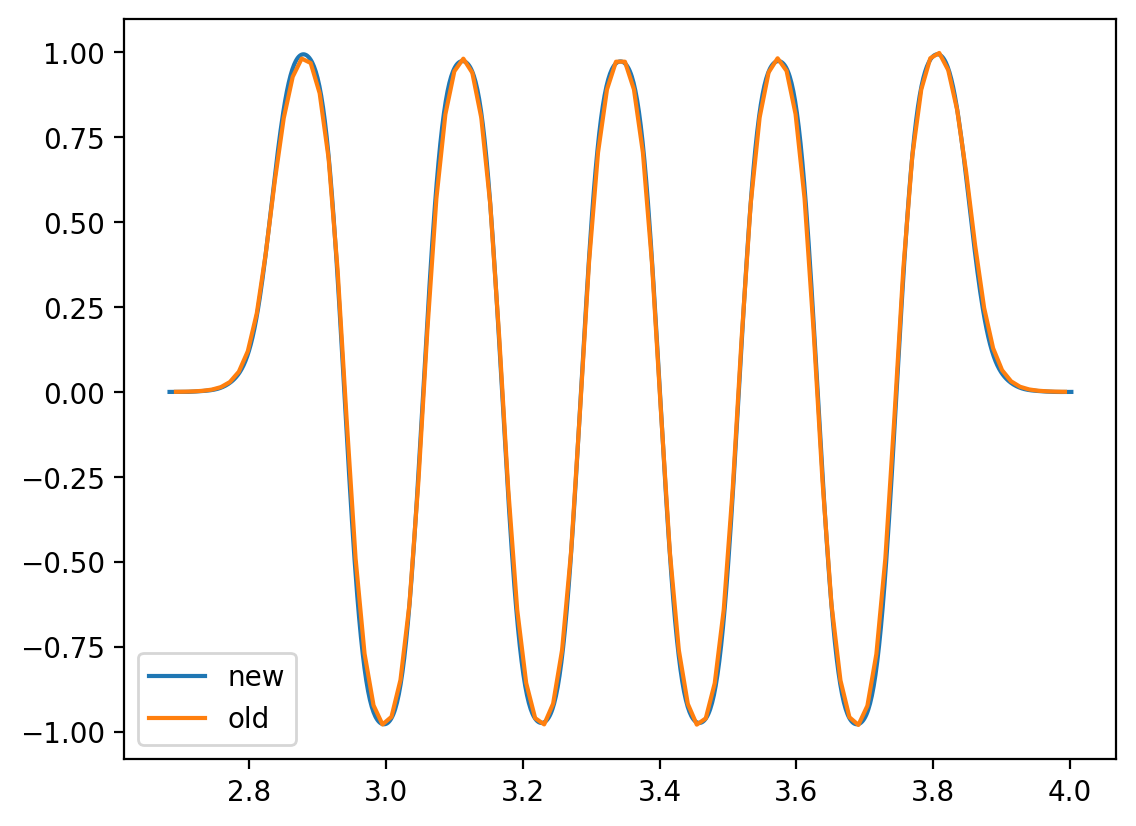

In [26]:
fig, ax = plt.subplots()
ax.plot(z0+zedge0, Ez0, label='new')
ax.plot(z1+zedge1, Ez1, label='old')
plt.legend()

# Compare phasing

In [27]:
from impact import Impact

I0 = Impact('ImpactT.in')
I1 = Impact('../v1/ImpactT.in')

In [28]:
settings = {}
for name in [
            'RFGUNB',
            'BUN1B',
            'SOL1B', 'SOL2B',
            'CAVL011',
            'CAVL012',
            'CAVL013',
            'CAVL014',
            'CAVL015',
            'CAVL016',
            'CAVL017',
            'CAVL018',
            ]:
    ele0 = I0.ele[name]
    ele1 = I1.ele[name]
    
    type = ele0['type']
    if type == 'solrf':
        theta0 = ele0['theta0_deg']
        theta1 = ele1['theta0_deg']
        scale0 = ele0['rf_field_scale']
        scale1 = ele1['rf_field_scale']
        bscale0 = ele0['solenoid_field_scale']
        bscale1 = ele1['solenoid_field_scale']        
        
        if scale0 < 0:
            scale0 *= -1
            theta0 += 180
            
        theta0 = (theta0 + 360) % 360 
        theta1 = (theta1 + 360) % 360 
        
        line = f"{theta0:10.6f} {theta1:10.6f} {scale0:10.6f} {scale1:10.6f} {bscale0:10.6f} {bscale1:10.6f}"
        
        settings[f"{name}:rf_field_scale"] = scale0
        settings[f"{name}:theta0_deg"] = theta0
        settings[f"{name}:solenoid_field_scale"] = bscale0
        
        print(line)
settings
    
    
    

178.219430 179.919665 20000000.000000 20000000.000000   0.000000   0.000000
203.563300 216.768502 1800000.000000 1800000.000000   0.000000   0.000000
  0.000000   0.000000   0.000000   0.000000   0.056000   0.055900
  0.000000   0.000000   0.000000   0.000000   0.030000   0.029900
261.847618 279.787224 11000000.000000 11000000.000000   0.000000   0.000000
 55.506251  11.682144  -0.000000   1.000000   0.000000   0.000000
254.777302 238.654847 26000000.000000 26000000.000000   0.000000   0.000000
241.880684 283.758157 21000000.000000 23500000.000000   0.000000   0.000000
230.006861 257.606079 32000000.000000 32000000.000000   0.000000   0.000000
250.908565 249.547729 32000000.000000 32000000.000000   0.000000   0.000000
250.906900 257.598394 32000000.000000 32000000.000000   0.000000   0.000000
250.944183 257.629085 32000000.000000 32000000.000000   0.000000   0.000000


{'RFGUNB:rf_field_scale': 20000000.0,
 'RFGUNB:theta0_deg': 178.21943,
 'RFGUNB:solenoid_field_scale': 0.0,
 'BUN1B:rf_field_scale': 1800000.0,
 'BUN1B:theta0_deg': 203.56330000000003,
 'BUN1B:solenoid_field_scale': 0.0,
 'SOL1B:rf_field_scale': 0.0,
 'SOL1B:theta0_deg': 0.0,
 'SOL1B:solenoid_field_scale': 0.056,
 'SOL2B:rf_field_scale': 0.0,
 'SOL2B:theta0_deg': 0.0,
 'SOL2B:solenoid_field_scale': 0.03,
 'CAVL011:rf_field_scale': 11000000.0,
 'CAVL011:theta0_deg': 261.8476175814001,
 'CAVL011:solenoid_field_scale': 0.0,
 'CAVL012:rf_field_scale': -0.0,
 'CAVL012:theta0_deg': 55.50625101959997,
 'CAVL012:solenoid_field_scale': 0.0,
 'CAVL013:rf_field_scale': 26000000.0,
 'CAVL013:theta0_deg': 254.77730237499998,
 'CAVL013:solenoid_field_scale': 0.0,
 'CAVL014:rf_field_scale': 21000000.0,
 'CAVL014:theta0_deg': 241.88068442259998,
 'CAVL014:solenoid_field_scale': 0.0,
 'CAVL015:rf_field_scale': 32000000.0,
 'CAVL015:theta0_deg': 230.00686122959996,
 'CAVL015:solenoid_field_scale': 0.0,


In [29]:
320 % 360

320

In [172]:
np.sqrt(10_000_000)

3162.2776601683795